# Finite Strain Contact

Compute the deformation of an elastic half-ring pushed against an elastic block. The results are then compared with those reported in [1, pp. 110-114].
Contact uses the current-length penalty potential in [2], Eq. (13), its first and second variations, Eqs. (15) and (21), and the outer active-set iteration in Box 2.
Segment-endpoint projections use the squared distance to the closest vertex with its consistent derivatives; this completes the search at corners of the discrete master surface.
Newton uses residual backtracking and a positive-det(F) check.

## Reference

[1] Rabii Mlika, *Nitsche Method for Frictional Contact and Self-Contact: Mathematical and Numerical Study*, 2019.

[2] K. A. Fischer and P. Wriggers, *Frictionless 2D Contact formulations for finite deformations based on the mortar method*, 2005.


In [ ]:
import gmsh
import dolfinx.fem.petsc
from mpi4py import MPI
import viskex
import pyvista as pv
import ufl
import numpy as np
from petsc4py import PETSc
from pathlib import Path
import shutil
from matplotlib import pyplot as plt

rank = 0
comm = MPI.COMM_WORLD

pv.set_jupyter_backend("static")

# Results folder
results = Path("./results_contact_finite_strain")
if results.exists():
    shutil.rmtree(results)
results.mkdir()

# Mesh properties
pdim = 0
bdim = 1
gdim = 2

BODY_1 = 1
BODY_2 = 2
BODY_3 = 3

ARCH_CONTACT    = 4
BASE_BOTTOM     = 5
BASE_TOP        = 6

ARCH_ENDS   = 7
MIDDLE      = 8
DISP        = 9
SYM         = 10

element = ("Lagrange", 1, (gdim,))

# Contact properties
gauss_xi = np.array([
    0.0694318442029737,
    0.3300094782075719,
    0.6699905217924281,
    0.9305681557970262
])

gauss_w = np.array([
    0.1739274225687269,
    0.3260725774312730,
    0.3260725774312730,
    0.1739274225687269
])

num_gauss   = 4
penalty_eps = 7.5e3

N1 = lambda xi: (1 - xi)
N2 = lambda xi: xi

# Material properties
E1 = 1e3
E2 = 1e5
E3 = 3e2
nu = 0.3

# Iteration tolerances
max_iter            = 500
steps               = 140  # increments: 141 states including u=0
U_goal              = -70
tol                 = 1e-6  # norm of the residual on free DOFs
alpha               = 1.0
max_contact_iter    = 200
max_backtracks      = 100
verbose_newton      = False


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 10%] Meshing curve 2 (Circle)
Info    : [ 20%] Meshing curve 3 (Circle)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 70%] Meshing curve 8 (Line)
Info    : [ 80%] Meshing curve 9 (Line)
Info    : [ 90%] Meshing curve 10 (Line)
Info    : [100%] Meshing curve 11 (Line)
Info    : Done meshing 1D (Wall 0.00089386s, CPU 0.001765s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 40%] Meshing surface 2 (Transfinite)
Info    : [ 70%] Meshing surface 3 (Transfinite)
Info    : Done meshing 2D (Wall 0.0025165s, CPU 0.002742s)
Info    : 627 nodes 1325 elements
Info    : Recombining 2D mesh...
Info    : Blossom: 323 internal 132 closed
Info    : Blossom recombination completed (Wall 0.0144738s, CPU 0.014523s): 130 quads, 0 triangles, 0 invalid quads, 0 quads wit

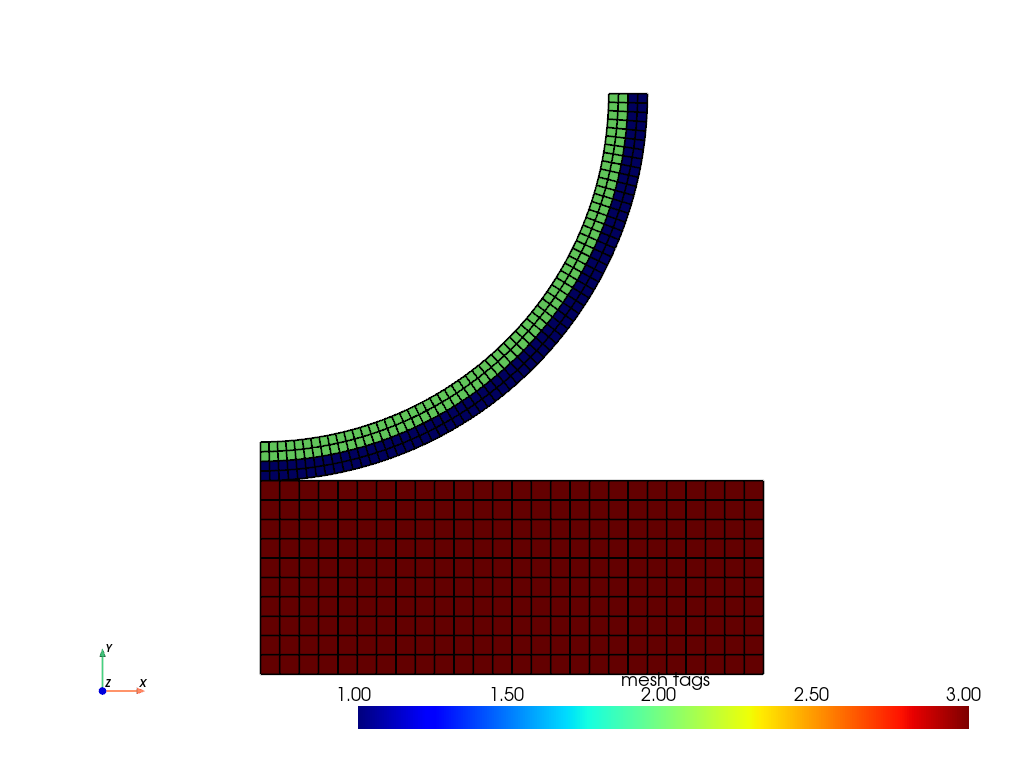

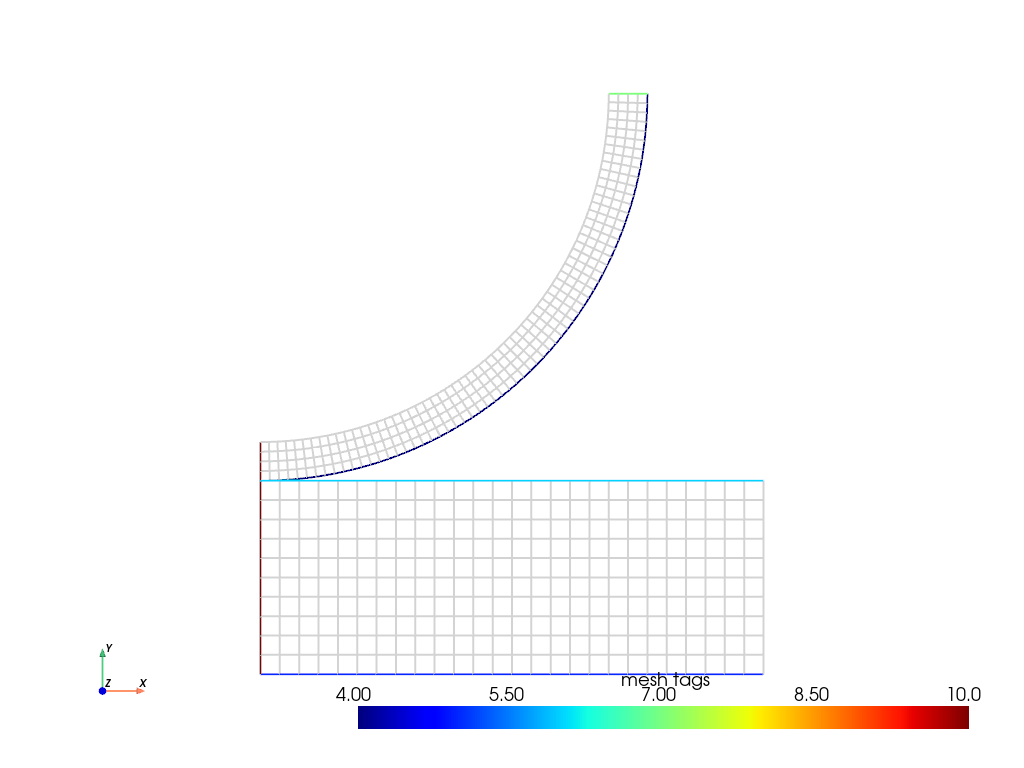

In [20]:
gmsh.initialize()
gmsh.model.add("finite-strain")

occ = gmsh.model.occ

# Lines and Surfaces
occ.add_circle(0, 0, 0, 100, angle1=3/2*np.pi, angle2=0)
occ.add_circle(0, 0, 0, 95, angle1=3/2*np.pi, angle2=0)
occ.add_circle(0, 0, 0, 90, angle1=3/2*np.pi, angle2=0)

occ.add_line(2, 4)
occ.add_line(4, 6)
occ.add_line(5, 3)
occ.add_line(3, 1)

occ.add_curve_loop([1, 4, -2, 7])
occ.add_curve_loop([2, 5, -3, 6])
occ.add_plane_surface([1])
occ.add_plane_surface([2])
occ.add_rectangle(0, -100-50, 0, 130, 50)

occ.synchronize()

# Physical tags
gmsh.model.add_physical_group(gdim, [1], BODY_1)
gmsh.model.add_physical_group(gdim, [2], BODY_2)
gmsh.model.add_physical_group(gdim, [3], BODY_3)

gmsh.model.add_physical_group(bdim, [1], ARCH_CONTACT)
gmsh.model.add_physical_group(bdim, [8], BASE_BOTTOM)
gmsh.model.add_physical_group(bdim, [10], BASE_TOP)

gmsh.model.add_physical_group(bdim, [4, 5], ARCH_ENDS)
gmsh.model.add_physical_group(pdim, [5], MIDDLE)
gmsh.model.add_physical_group(bdim, [6, 7, 11], SYM)

# Transfinite mesh
for curve_id in (4, 5, 6, 7):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 3)

for curve_id in (1, 2, 3):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 66)

for curve_id in (11, -9):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 11)

for curve_id in (8, -10):
    gmsh.model.mesh.set_transfinite_curve(curve_id, 27)

gmsh.model.mesh.set_transfinite_surface(1)
gmsh.model.mesh.set_transfinite_surface(2)
gmsh.model.mesh.set_transfinite_surface(3)
gmsh.model.mesh.generate(gdim)
gmsh.model.mesh.recombine()
mesh_data = dolfinx.io.gmsh.model_to_mesh(gmsh.model, comm, rank, gdim)
gmsh.finalize()

domain          = mesh_data.mesh
facet_tags      = mesh_data.facet_tags
cell_tags       = mesh_data.cell_tags
ridge_tags      = mesh_data.ridge_tags

middle_idx      = ridge_tags.find(MIDDLE).item()
slave_facets    = facet_tags.find(ARCH_CONTACT)
master_facets   = facet_tags.find(BASE_TOP)

tdim            = domain.topology.dim
fdim            = tdim - 1
x_current       = domain.geometry.x[:, :tdim].copy()
facet_to_node   = domain.topology.connectivity(1, 0)
facet_to_cell   = domain.topology.connectivity(1, 2)
cell_to_node    = domain.topology.connectivity(2, 0)

viskex.dolfinx.plot_mesh_tags(domain, cell_tags)
viskex.dolfinx.plot_mesh_tags(domain, facet_tags)

In [21]:
def neo_hookean_energy(u, E, nu):
    C10 = E / (4.0 * (1.0 + nu))
    D1  = 6 * (1 - 2*nu) / E

    i2 = ufl.Identity(tdim)
    f2 = i2 + ufl.grad(u)
    f3 = ufl.as_tensor(
        (
            (f2[0, 0], f2[0, 1], 0.0),
            (f2[1, 0], f2[1, 1], 0.0),
            (0.0, 0.0, 1.0),
        )
    )
    j = ufl.det(f2)
    c3 = f3.T * f3
    i1 = ufl.tr(c3)

    i1_bar = j ** (-2.0 / 3.0) * i1
    return C10 * (i1_bar - 3.0) +  1/D1 * (j - 1.0) ** 2

def closest_segment(x1):
    """Closest point on the piecewise linear master, including its vertices."""
    nodes = np.array([facet_to_node.links(s) for s in master_facets])
    x21, x22 = x_current[nodes[:, 0]], x_current[nodes[:, 1]]
    a2 = x22 - x21
    xi2 = np.einsum("ij,ij->i", x1 - x21, a2) / np.einsum("ij,ij->i", a2, a2)
    # An out-of-segment perpendicular projection can still have the nearest
    # master vertex as its closest point. Discarding it leaves contact holes.
    xi2 = np.clip(xi2, 0.0, 1.0)
    x2 = x21 + xi2[:, None] * a2
    distance2 = np.einsum("ij,ij->i", x1 - x2, x1 - x2)
    nearest = np.argmin(distance2)
    return True, master_facets[nearest], xi2[nearest]


def segment_normal(segment, x21, x22):
    cell = facet_to_cell.links(segment).item()
    centroid = x_current[cell_to_node.links(cell)].mean(axis=0)
    a2 = x22 - x21
    normal = np.array([a2[1], -a2[0]]) / np.linalg.norm(a2)
    if np.dot(normal, centroid - 0.5 * (x21 + x22)) > 0:
        normal *= -1.0
    return normal


def active_segments():
    """Pointwise penalty contact test, Fischer/Wriggers Eq. (57)."""
    active = []
    for segment in slave_facets:
        x11, x12 = x_current[facet_to_node.links(segment)]
        for i, xi1 in enumerate(gauss_xi):
            x1 = N1(xi1) * x11 + N2(xi1) * x12
            _, master, xi2 = closest_segment(x1)
            x21, x22 = x_current[facet_to_node.links(master)]
            x2 = N1(xi2) * x21 + N2(xi2) * x22
            normal = segment_normal(master, x21, x22)
            # At a closest vertex this dot product supplies the sign of the
            # signed distance. Its magnitude is not the vertex distance.
            if np.dot(x1 - x2, normal) <= 0.0:
                active.append((segment, i))
    return active


def active_keys(active):
    return {(int(slave), int(igp)) for slave, igp in active}


def assemble_contact(J, R, active):
    """Assemble d(Pi_c) and d²(Pi_c); J=None only assembles the residual.

    Pi_c = sum_GP 0.5 * w * penalty_eps * g_N**2 * l_slave.
    The active Gauss points stay fixed in an inner Newton solve (Box 2).
    The closest master point is recomputed in the current configuration.
    """
    for segment, i in active:
        xi1, weight = gauss_xi[i], gauss_w[i]
        slave_nodes = facet_to_node.links(segment)
        x11, x12 = x_current[slave_nodes]
        a1 = x12 - x11
        l1 = np.linalg.norm(a1)
        t1 = a1 / l1
        x1 = N1(xi1) * x11 + N2(xi1) * x12

        _, master, xi2 = closest_segment(x1)
        master_nodes = facet_to_node.links(master)
        x21, x22 = x_current[master_nodes]
        a2 = x22 - x21
        l2 = np.linalg.norm(a2)
        t2 = a2 / l2
        x2 = N1(xi2) * x21 + N2(xi2) * x22
        n2 = segment_normal(master, x21, x22)
        gap_vector = x1 - x2
        gN = np.dot(gap_vector, n2)

        nodes = np.concatenate((slave_nodes, master_nodes))
        rows = (2 * nodes[:, None] + np.arange(2)).ravel().astype(PETSc.IntType)
        Hc = np.kron([[N1(xi1), N2(xi1), -N1(xi2), -N2(xi2)]], np.eye(2))
        A1 = np.zeros((2, 8))
        A1[:, :2], A1[:, 2:4] = -np.eye(2), np.eye(2)
        L = A1.T @ t1                       # gradient of current slave length
        endpoint = xi2 == 0.0 or xi2 == 1.0

        if endpoint:
            # Closest-vertex extension: Pi_c = 0.5*w*eps*l1*|x1-x_vertex|².
            # Differentiating this directly also works at zero distance.
            gap2 = np.dot(gap_vector, gap_vector)
            D = Hc.T @ gap_vector
            Fc = weight * penalty_eps * (l1 * D + 0.5 * gap2 * L)
        else:
            B = Hc.T @ n2                   # gradient of the signed normal gap
            # Fischer/Wriggers Eq. (15): keep the variation of da = l1*d(xi1).
            Fc = weight * penalty_eps * (gN * l1 * B + 0.5 * gN**2 * L)
        R.setValues(rows, Fc, addv=PETSc.InsertMode.ADD_VALUES)
        if J is None:
            continue

        Hl = A1.T @ ((np.eye(2) - np.outer(t1, t1)) / l1) @ A1
        if endpoint:
            Kc = weight * penalty_eps * (
                l1 * (Hc.T @ Hc)
                + np.outer(D, L) + np.outer(L, D) + 0.5 * gap2 * Hl
            )
        else:
            A2 = np.zeros((2, 8))
            A2[:, 4:6], A2[:, 6:8] = -np.eye(2), np.eye(2)
            v, wN = Hc.T @ t2, A2.T @ n2
            # Consistent gap Hessian: includes the sliding projection and normal.
            Hg = (
                -(np.outer(v, wN) + np.outer(wN, v)) / l2
                - gN / l2**2 * np.outer(wN, wN)
            )
            # Eq. (21), equivalently Appendix B: all five terms are needed.
            Kc = weight * penalty_eps * (
                l1 * np.outer(B, B) + gN * l1 * Hg
                + gN * (np.outer(B, L) + np.outer(L, B)) + 0.5 * gN**2 * Hl
            )
        J.setValues(rows, rows, Kc, addv=PETSc.InsertMode.ADD_VALUES)

dx = ufl.Measure("dx", domain, subdomain_data=cell_tags)
ds = ufl.Measure("ds", domain, subdomain_data=facet_tags)

V = dolfinx.fem.functionspace(domain, element)

uh          = dolfinx.fem.Function(V, name="u")
du          = dolfinx.fem.Function(V)
v           = ufl.TestFunction(V)
du_trial    = ufl.TrialFunction(V)

# Dirichlet
U = dolfinx.fem.Constant(domain, [0.0, 0.0])

bc_symmetry = dolfinx.fem.dirichletbc(
    dolfinx.default_scalar_type(0.0),
    dolfinx.fem.locate_dofs_topological(V.sub(0), fdim, facet_tags.find(SYM)),
    V.sub(0),
)

bc_bottom = dolfinx.fem.dirichletbc(
    dolfinx.default_scalar_type([0.0, 0.0]),
    dolfinx.fem.locate_dofs_topological(V, fdim, facet_tags.find(BASE_BOTTOM)),
    V,
)

bc_ends = dolfinx.fem.dirichletbc(
    U,
    dolfinx.fem.locate_dofs_topological(V, fdim, facet_tags.find(ARCH_ENDS)),
    V,
)

bcs = [bc_symmetry, bc_bottom, bc_ends]

bc_dofs = []
for bc in bcs:
    bc.set(uh.x.array)
    indices, unrolled = bc.dof_indices()
    bc_dofs.extend(indices)
bc_dofs = np.unique(bc_dofs).astype(np.int32)

# Material
Psi1 = neo_hookean_energy(uh, E1, nu)
Psi2 = neo_hookean_energy(uh, E2, nu)
Psi3 = neo_hookean_energy(uh, E3, nu)
Psi_total = Psi1 * dx(BODY_1) + Psi2 * dx(BODY_2) + Psi3 * dx(BODY_3)

residual    = ufl.derivative(Psi_total, uh, v)
jacobian    = ufl.derivative(residual, uh, du_trial)
R_form      = dolfinx.fem.form(residual)
J_form      = dolfinx.fem.form(jacobian)

R = dolfinx.fem.petsc.create_vector(dolfinx.fem.extract_function_spaces(R_form))
J = dolfinx.fem.petsc.create_matrix(J_form)

# Solver
solver = PETSc.KSP().create(domain.comm)
solver.setOperators(J)
solver.setType("preonly")
solver.getPC().setType("lu")

out_file = dolfinx.io.XDMFFile(comm, results / "disp.xdmf", "w")
out_file.write_mesh(domain)

# Check det(F) at the corners of every Q1 quadrilateral before evaluating J**(-2/3).
cell_indices = np.arange(domain.topology.index_map(tdim).size_local, dtype=np.int32)
detF_expression = dolfinx.fem.Expression(
    ufl.det(ufl.Identity(tdim) + ufl.grad(uh)),
    np.array([[0., 0.], [1., 0.], [0., 1.], [1., 1.]])
)

def update_geometry():
    uh.x.scatter_forward()
    x_current[:] = domain.geometry.x[:, :tdim] + uh.x.array.reshape(-1, 2)


def min_detF():
    return float(np.min(detF_expression.eval(domain, cell_indices)))


def assemble_system(active, tangent=True):
    with R.localForm() as local:
        local.set(0.0)
    if tangent:
        J.zeroEntries()
        dolfinx.fem.petsc.assemble_matrix(J, J_form)
    dolfinx.fem.petsc.assemble_vector(R, R_form)
    assemble_contact(J if tangent else None, R, active)
    if tangent:
        J.assemble()
        J.zeroRowsColumns(bc_dofs, diag=1.0)
    R.assemble()
    R.setValues(bc_dofs, np.zeros(len(bc_dofs)), addv=PETSc.InsertMode.INSERT_VALUES)
    R.assemble()
    return R.norm()

J.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
rhs = R.duplicate()
u_imposed = np.linspace(0, U_goal, steps + 1)
u_fenicsx = np.zeros_like(u_imposed)
min_det_history = []
residual_history = []

try:
    for istep, u_current in enumerate(u_imposed):
        U.value[:] = [0.0, u_current]
        for bc in bcs:
            bc.set(uh.x.array)
        update_geometry()
        if min_detF() <= 0:
            raise RuntimeError(f'Invalid starting deformation at load step {istep}')
        active = active_segments()
        for contact_iter in range(max_contact_iter):
            for iteration in range(max_iter):
                residual_norm = assemble_system(active)
                if not np.isfinite(residual_norm):
                    raise RuntimeError(f'Non-finite residual at load step {istep}')
                if residual_norm < tol:
                    break
                R.copy(rhs)
                rhs.scale(-1.0)
                solver.solve(rhs, du.x.petsc_vec)
                if solver.getConvergedReason() <= 0 or not np.all(np.isfinite(du.x.array)):
                    raise RuntimeError(f'Linear solve failed at load step {istep}')
                u_before = uh.x.array.copy()
                step_length = alpha
                for backtrack in range(max_backtracks):
                    uh.x.array[:] = u_before + step_length * du.x.array
                    update_geometry()
                    trial_det = min_detF()
                    if np.isfinite(trial_det) and trial_det > 1e-8:
                        trial_norm = assemble_system(active, tangent=False)
                        if np.isfinite(trial_norm) and trial_norm <= (1.0 - 1e-4 * step_length) * residual_norm:
                            break
                    step_length *= 0.5
                else:
                    uh.x.array[:] = u_before
                    update_geometry()
                    raise RuntimeError(f'Line search failed at step {istep}, contact {contact_iter}, residual {residual_norm}')
                if verbose_newton:
                    print(f'Step {istep:3d}, contact {contact_iter:2d}, iteration {iteration:2d}, '
                          f'residual {trial_norm:.3e}, alpha {step_length:.3e}, detF {trial_det:.4f}')
            else:
                raise RuntimeError(f'Newton did not converge at step {istep}')
            new_active = active_segments()
            if active_keys(new_active) == active_keys(active):
                break
            active = new_active
        else:
            raise RuntimeError(f'Contact set did not stabilize at step {istep}')
        u_fenicsx[istep] = uh.x.array.reshape(-1, 2)[middle_idx, 1]
        min_det_history.append(min_detF())
        residual_history.append(residual_norm)
        out_file.write_function(uh, istep)
        print(f'Step {istep:3d}/{steps}, u={u_current:.1f}, '
              f'u_middle={u_fenicsx[istep]:.6f}, residual={residual_norm:.2e}, '
              f'min(detF)={min_det_history[-1]:.4f}')
finally:
    out_file.close()
    rhs.destroy()


Step   0/140, u=0.0, u_middle=0.000000, residual=5.61e-11, min(detF)=1.0000
Step   1/140, u=-0.5, u_middle=-0.237129, residual=2.05e-10, min(detF)=0.9843
Step   2/140, u=-1.0, u_middle=-0.443331, residual=2.36e-10, min(detF)=0.9736
Step   3/140, u=-1.5, u_middle=-0.636636, residual=2.53e-10, min(detF)=0.9652
Step   4/140, u=-2.0, u_middle=-0.801839, residual=4.16e-10, min(detF)=0.9604
Step   5/140, u=-2.5, u_middle=-0.956709, residual=3.97e-10, min(detF)=0.9560
Step   6/140, u=-3.0, u_middle=-1.102697, residual=2.15e-09, min(detF)=0.9521
Step   7/140, u=-3.5, u_middle=-1.243713, residual=6.89e-10, min(detF)=0.9484
Step   8/140, u=-4.0, u_middle=-1.365101, residual=6.95e-10, min(detF)=0.9460
Step   9/140, u=-4.5, u_middle=-1.477761, residual=7.51e-10, min(detF)=0.9440
Step  10/140, u=-5.0, u_middle=-1.582117, residual=2.34e-09, min(detF)=0.9424
Step  11/140, u=-5.5, u_middle=-1.682691, residual=8.33e-10, min(detF)=0.9409
Step  12/140, u=-6.0, u_middle=-1.774525, residual=1.03e-09, min(d

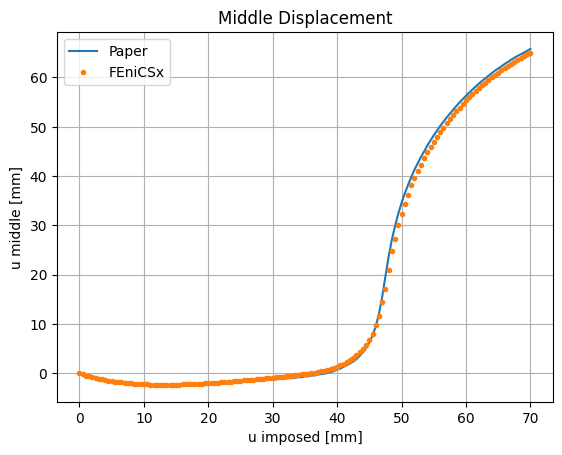

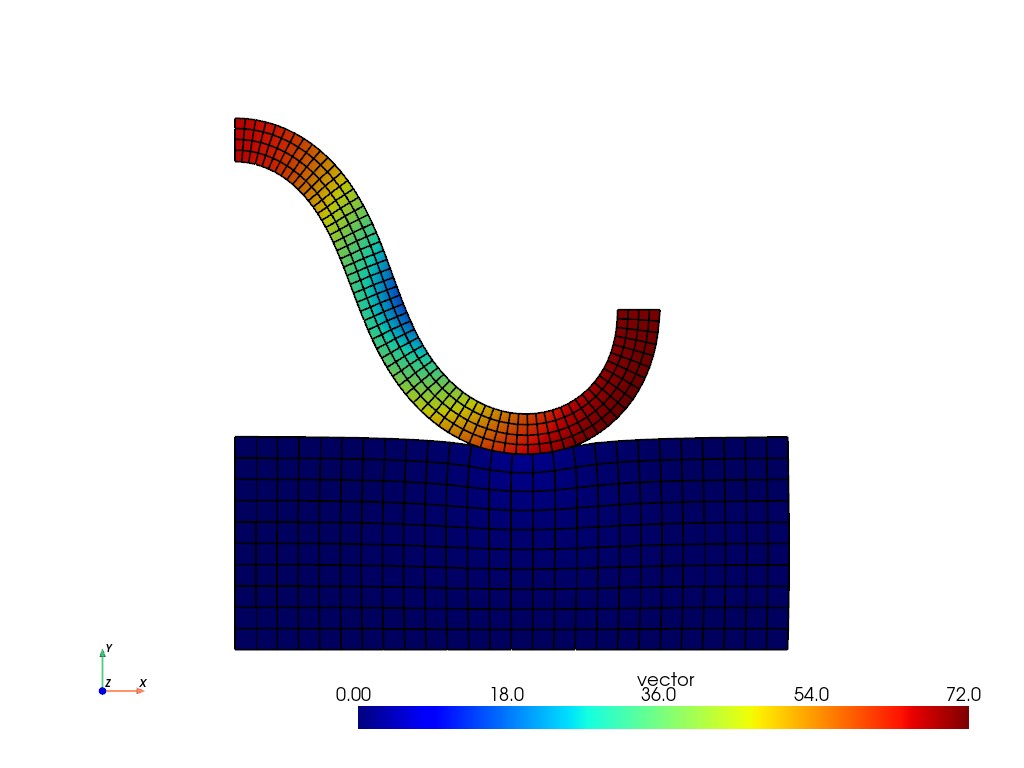

In [22]:
ref_data = np.array([
    [0.0, 0.000],
    [0.5, -0.291],
    [1.0, -0.438],
    [1.5, -0.613],
    [2.0, -0.787],
    [2.5, -0.961],
    [3.0, -1.135],
    [3.5, -1.244],
    [4.0, -1.309],
    [4.5, -1.483],
    [5.0, -1.571],
    [5.5, -1.658],
    [6.0, -1.832],
    [6.5, -1.832],
    [7.0, -1.919],
    [7.5, -2.006],
    [8.0, -2.006],
    [8.5, -2.180],
    [9.0, -2.180],
    [9.5, -2.180],
    [10.0, -2.265],
    [10.5, -2.354],
    [11.0, -2.354],
    [11.5, -2.354],
    [12.0, -2.354],
    [12.5, -2.354],
    [13.0, -2.354],
    [13.5, -2.354],
    [14.0, -2.354],
    [14.5, -2.354],
    [15.0, -2.354],
    [15.5, -2.354],
    [16.0, -2.354],
    [16.5, -2.354],
    [17.0, -2.354],
    [17.5, -2.354],
    [18.0, -2.354],
    [18.5, -2.267],
    [19.0, -2.188],
    [19.5, -2.180],
    [20.0, -2.180],
    [20.5, -2.180],
    [21.0, -2.180],
    [21.5, -2.093],
    [22.0, -2.006],
    [22.5, -2.006],
    [23.0, -2.006],
    [23.5, -1.919],
    [24.0, -1.832],
    [24.5, -1.832],
    [25.0, -1.832],
    [25.5, -1.745],
    [26.0, -1.658],
    [26.5, -1.658],
    [27.0, -1.658],
    [27.5, -1.483],
    [28.0, -1.483],
    [28.5, -1.483],
    [29.0, -1.396],
    [29.5, -1.309],
    [30.0, -1.309],
    [30.5, -1.222],
    [31.0, -1.135],
    [31.5, -1.135],
    [32.0, -1.048],
    [32.5, -0.961],
    [33.0, -0.961],
    [33.5, -0.874],
    [34.0, -0.787],
    [34.5, -0.787],
    [35.0, -0.613],
    [35.5, -0.613],
    [36.0, -0.449],
    [36.5, -0.438],
    [37.0, -0.264],
    [37.5, -0.160],
    [38.0, -0.090],
    [38.5, 0.084],
    [39.0, 0.258],
    [39.5, 0.432],
    [40.0, 0.781],
    [40.5, 0.955],
    [41.0, 1.303],
    [41.5, 1.628],
    [42.0, 2.000],
    [42.5, 2.401],
    [43.0, 2.879],
    [43.5, 3.523],
    [44.0, 4.258],
    [44.5, 5.167],
    [45.0, 6.234],
    [45.5, 7.638],
    [46.0, 9.495],
    [46.5, 12.071],
    [47.0, 15.535],
    [47.5, 19.683],
    [48.0, 23.658],
    [48.5, 27.119],
    [49.0, 29.894],
    [49.5, 32.399],
    [50.0, 34.537],
    [50.5, 36.480],
    [51.0, 38.155],
    [51.5, 39.758],
    [52.0, 41.269],
    [52.5, 42.565],
    [53.0, 43.860],
    [53.5, 44.982],
    [54.0, 46.191],
    [54.5, 47.226],
    [55.0, 48.260],
    [55.5, 49.208],
    [56.0, 50.155],
    [56.5, 51.021],
    [57.0, 51.876],
    [57.5, 52.665],
    [58.0, 53.423],
    [58.5, 54.196],
    [59.0, 54.945],
    [59.5, 55.605],
    [60.0, 56.253],
    [60.5, 56.941],
    [61.0, 57.549],
    [61.5, 58.140],
    [62.0, 58.739],
    [62.5, 59.299],
    [63.0, 59.821],
    [63.5, 60.343],
    [64.0, 60.866],
    [64.5, 61.386],
    [65.0, 61.811],
    [65.5, 62.259],
    [66.0, 62.722],
    [66.5, 63.130],
    [67.0, 63.582],
    [67.5, 64.001],
    [68.0, 64.349],
    [68.5, 64.698],
    [69.0, 65.046],
    [69.5, 65.394],
    [70.0, 65.794]
])

u_imposed2  = ref_data[:, 0]
u_ref       = ref_data[:, 1]

plt.plot(u_imposed2, u_ref)
plt.plot(-u_imposed, u_fenicsx, ".")
plt.legend(["Paper", "FEniCSx"])
plt.xlabel("u imposed [mm]")
plt.ylabel("u middle [mm]")
plt.title("Middle Displacement")
plt.grid(True)
plt.show()

viskex.dolfinx.plot_vector_field(uh, warp_factor=1)